In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install torch-pruning
!pip install torchinfo

In [ ]:
import torch
import torch_pruning as tp
from torchvision import models
import inspect
import torch.nn as nn



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_classes = 1

import torch.nn as nn

model.fc = nn.Sequential(
nn.Flatten(),
nn.Dropout(0.3),
nn.Linear(512, 256),
nn.ReLU(),
nn.Dropout(0.3),
nn.Linear(256, num_classes))



state = torch.load("/content/state_dict_RN18.pth", map_location=device) #<--- change this to your state_dict.pth model
model.load_state_dict(state)
model = model.to(device)
model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
print("-----------------------------------Before pruning------------------------------------")
from torchinfo import summary

summary(model, input_size=(1, 3, 224, 224))


-----------------------------------Before pruning------------------------------------


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1]                    --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

In [ ]:
print("---------------- before pruning ---------------- ")
from torchsummary import summary
original_model = summary(model, (3, 224, 224))


---------------- before pruning ---------------- 
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]      

In [ ]:
with torch.no_grad():
    x = torch.randn(1,3,224,224).to(device)
    y = model(x)
    print(y.shape)


torch.Size([1, 1])


In [ ]:
# 1) Shapes
print("Conv shapes before pruning:")
for name, m in model.named_modules():
    if isinstance(m, torch.nn.Conv2d):
        print(name, m.weight.shape)

Conv shapes before pruning:
conv1 torch.Size([64, 3, 7, 7])
layer1.0.conv1 torch.Size([64, 64, 3, 3])
layer1.0.conv2 torch.Size([64, 64, 3, 3])
layer1.1.conv1 torch.Size([64, 64, 3, 3])
layer1.1.conv2 torch.Size([64, 64, 3, 3])
layer2.0.conv1 torch.Size([128, 64, 3, 3])
layer2.0.conv2 torch.Size([128, 128, 3, 3])
layer2.0.downsample.0 torch.Size([128, 64, 1, 1])
layer2.1.conv1 torch.Size([128, 128, 3, 3])
layer2.1.conv2 torch.Size([128, 128, 3, 3])
layer3.0.conv1 torch.Size([256, 128, 3, 3])
layer3.0.conv2 torch.Size([256, 256, 3, 3])
layer3.0.downsample.0 torch.Size([256, 128, 1, 1])
layer3.1.conv1 torch.Size([256, 256, 3, 3])
layer3.1.conv2 torch.Size([256, 256, 3, 3])
layer4.0.conv1 torch.Size([512, 256, 3, 3])
layer4.0.conv2 torch.Size([512, 512, 3, 3])
layer4.0.downsample.0 torch.Size([512, 256, 1, 1])
layer4.1.conv1 torch.Size([512, 512, 3, 3])
layer4.1.conv2 torch.Size([512, 512, 3, 3])


In [ ]:
 # Param and nonzero counts
total = sum(p.numel() for p in model.parameters())
nonzero = sum(torch.count_nonzero(p).item() for p in model.parameters())
print("Total params:", total)
print("Nonzero params:", nonzero)
print("Zero fraction:", 1 - nonzero/total)



Total params: 11308097
Nonzero params: 11308097
Zero fraction: 0.0


# **Pruning**


In [ ]:
!pip show torch-pruning

Name: torch-pruning
Version: 1.6.1
Summary: Towards Any Structural Pruning
Home-page: https://github.com/VainF/Torch-Pruning
Author: Gongfan Fang
Author-email: gongfan@u.nus.edu
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, torch
Required-by: 


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
example_inputs = torch.randn(1, 3, 224, 224).to(device)

In [ ]:
conv_list = []
for name, m in model.named_modules():
    if isinstance(m, torch.nn.Conv2d):
        conv_list.append((name, m))
print(f"Total Conv2d modules found: {len(conv_list)}")
print("Sample conv modules (name, in_c, out_c, k, groups):")
for name, m in conv_list[:20]:
    print(f"{name:40s} | in={m.in_channels:4d} out={m.out_channels:4d} k={m.kernel_size} g={m.groups}")

Total Conv2d modules found: 20
Sample conv modules (name, in_c, out_c, k, groups):
conv1                                    | in=   3 out=  64 k=(7, 7) g=1
layer1.0.conv1                           | in=  64 out=  64 k=(3, 3) g=1
layer1.0.conv2                           | in=  64 out=  64 k=(3, 3) g=1
layer1.1.conv1                           | in=  64 out=  64 k=(3, 3) g=1
layer1.1.conv2                           | in=  64 out=  64 k=(3, 3) g=1
layer2.0.conv1                           | in=  64 out= 128 k=(3, 3) g=1
layer2.0.conv2                           | in= 128 out= 128 k=(3, 3) g=1
layer2.0.downsample.0                    | in=  64 out= 128 k=(1, 1) g=1
layer2.1.conv1                           | in= 128 out= 128 k=(3, 3) g=1
layer2.1.conv2                           | in= 128 out= 128 k=(3, 3) g=1
layer3.0.conv1                           | in= 128 out= 256 k=(3, 3) g=1
layer3.0.conv2                           | in= 256 out= 256 k=(3, 3) g=1
layer3.0.downsample.0                    

In [ ]:
prunable_candidates = []
for name, m in conv_list:
    if m.kernel_size == (3,3) and m.groups == 1: #standard 3×3 conv layers (no depthwise convs)
        prunable_candidates.append((name, m))

print(f"Prunable (3x3 conv, groups==1) candidates: {len(prunable_candidates)}")
for name, m in prunable_candidates[:10]:
    print(f" - {name}: in={m.in_channels}, out={m.out_channels}")


Prunable (3x3 conv, groups==1) candidates: 16
 - layer1.0.conv1: in=64, out=64
 - layer1.0.conv2: in=64, out=64
 - layer1.1.conv1: in=64, out=64
 - layer1.1.conv2: in=64, out=64
 - layer2.0.conv1: in=64, out=128
 - layer2.0.conv2: in=128, out=128
 - layer2.1.conv1: in=128, out=128
 - layer2.1.conv2: in=128, out=128
 - layer3.0.conv1: in=128, out=256
 - layer3.0.conv2: in=256, out=256


In [ ]:
# ignore the first conv (stem) and the final fully connected layer
ignored = []
for name, m in model.named_modules():
    if name == "conv1":
        ignored.append((name, m))
    if isinstance(m, torch.nn.Linear):
        ignored.append((name, m))

print(f"Ignored modules (stem conv + linear): {len(ignored)}")
for name, m in ignored:
    print(" -", name, type(m), getattr(m, "in_channels", None), getattr(m, "out_features", None))


Ignored modules (stem conv + linear): 3
 - conv1 <class 'torch.nn.modules.conv.Conv2d'> 3 None
 - fc.2 <class 'torch.nn.modules.linear.Linear'> None 256
 - fc.5 <class 'torch.nn.modules.linear.Linear'> None 1


In [ ]:
print("Device:", device)
print("Total params (before):", tp.utils.count_params(model))


Device: cuda
Total params (before): 11308097


In [ ]:
# L2 importance (magnitude-based pruning)
importance = tp.importance.MagnitudeImportance(p=2)


pruner = tp.pruner.MagnitudePruner(
    model=model,
    example_inputs=example_inputs,
    importance=importance,
    pruning_ratio=0.7,  # prune ratio of channels. adjust this
    ignored_layers=[m for _, m in ignored],
)


In [ ]:
print("Pruner created. Will run step() now.")
before_params = tp.utils.count_params(model)
pruner.step()
after_params = tp.utils.count_params(model)
print("Params before:", before_params)
print("Params after: ", after_params)


Pruner created. Will run step() now.
Params before: 11308097
Params after:  1092458


In [ ]:
print("-----------------------------------after pruning------------------------------------")
from torchinfo import summary

summary(model, input_size=(1, 3, 224, 224))



-----------------------------------after pruning------------------------------------


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1]                    --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 19, 56, 56]           10,944
│    │    └─BatchNorm2d: 3-2             [1, 19, 56, 56]           38
│    │    └─ReLU: 3-3                    [1, 19, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           10,944
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│ 

In [ ]:
print("---------------- after pruning ---------------- ")
from torchsummary import summary
original_model = summary(model, (3, 224, 224))


---------------- after pruning ---------------- 
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 19, 56, 56]          10,944
       BatchNorm2d-6           [-1, 19, 56, 56]              38
              ReLU-7           [-1, 19, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          10,944
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 19, 56, 56]          10,944
      BatchNorm2d-13           [-1, 19, 56, 56]       

In [ ]:
# 1) Shapes
print("Conv shapes after pruning:")
for name, m in model.named_modules():
    if isinstance(m, torch.nn.Conv2d):
        print(name, m.weight.shape)

# 2) Param and nonzero counts
total = sum(p.numel() for p in model.parameters())
nonzero = sum(torch.count_nonzero(p).item() for p in model.parameters())
print("Total params:", total)
print("Nonzero params:", nonzero)
print("Zero fraction:", 1 - nonzero/total)

#pruning will be notice in the 1×1 convs (like features.*.conv.0.0, features.*.conv.2, and the final features.18.0).
#Zero fraction: 0.0 means No unstructured zeroing (That means channels were removed, not just set to zero)


Conv shapes after pruning:
conv1 torch.Size([64, 3, 7, 7])
layer1.0.conv1 torch.Size([19, 64, 3, 3])
layer1.0.conv2 torch.Size([64, 19, 3, 3])
layer1.1.conv1 torch.Size([19, 64, 3, 3])
layer1.1.conv2 torch.Size([64, 19, 3, 3])
layer2.0.conv1 torch.Size([38, 64, 3, 3])
layer2.0.conv2 torch.Size([38, 38, 3, 3])
layer2.0.downsample.0 torch.Size([38, 64, 1, 1])
layer2.1.conv1 torch.Size([38, 38, 3, 3])
layer2.1.conv2 torch.Size([38, 38, 3, 3])
layer3.0.conv1 torch.Size([76, 38, 3, 3])
layer3.0.conv2 torch.Size([76, 76, 3, 3])
layer3.0.downsample.0 torch.Size([76, 38, 1, 1])
layer3.1.conv1 torch.Size([76, 76, 3, 3])
layer3.1.conv2 torch.Size([76, 76, 3, 3])
layer4.0.conv1 torch.Size([153, 76, 3, 3])
layer4.0.conv2 torch.Size([153, 153, 3, 3])
layer4.0.downsample.0 torch.Size([153, 76, 1, 1])
layer4.1.conv1 torch.Size([153, 153, 3, 3])
layer4.1.conv2 torch.Size([153, 153, 3, 3])
Total params: 1092458
Nonzero params: 1092458
Zero fraction: 0.0


In [ ]:
print (before_params ,after_params)

11308097 1092458


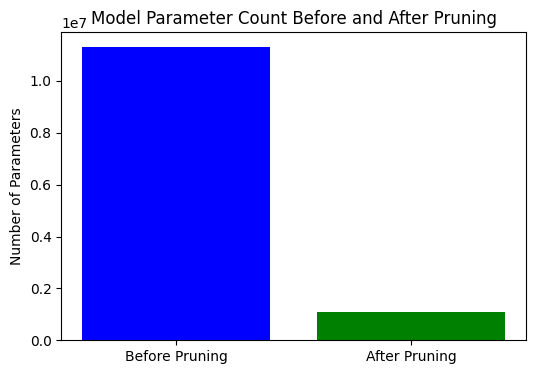

In [ ]:
import matplotlib.pyplot as plt

# Parameter counts obtained from previous execution

labels = ['Before Pruning', 'After Pruning']
param_counts = [before_params , after_params]

plt.figure(figsize=(6, 4))
plt.bar(labels, param_counts, color=['blue', 'green'])
plt.ylabel('Number of Parameters')
plt.title('Model Parameter Count Before and After Pruning')
plt.show()

In [ ]:
# ensures the pruning didn’t break the computation graph.
with torch.no_grad():
    x = torch.randn(1, 3, 224, 224).to(device)
    y = model(x)
    print("Output shape:", y.shape)


Output shape: torch.Size([1, 1])


#Fine-tuning

In [ ]:
import os
# ------------------------ for the splitting of dataset ------------------------
import random
from pathlib import Path
# ------------------------for the lebling of dataset ------------------------
from torchvision import datasets, transforms
from torch.utils.data import DataLoader #turn the dataset into iterable and also for batching
from PIL import Image
from typing import List
# ------------------------ for the training of the model as MobileNetV2 ------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models  # ------------------ For MobileNetV2 ( or any pretrained model )
from sklearn.metrics import precision_score, recall_score, f1_score
# ------------------------ for plotting the curves ------------------------
import matplotlib.pyplot as plt
# ------------------------ for getting the summary of the model ------------------------
from torchinfo import summary

In [ ]:
def walk_through_dir(dir_path):
    for dirpath, dirname, filenames in os.walk(dir_path):
        print(f"There are {len(dirname)} directories and {len(filenames)} images in '{dirpath}'")


# dataset_path = "/content/drive/MyDrive/colon_after_splitting"
dataset_path = "/content/drive/MyDrive/COVID19+PNEUMONIA+NORMAL Chest X-Ray Image Dataset"
# dataset_path = "/content/drive/MyDrive/K+F MRI"


walk_through_dir(dataset_path)

There are 3 directories and 0 images in '/content/drive/MyDrive/COVID19+PNEUMONIA+NORMAL Chest X-Ray Image Dataset'
There are 2 directories and 0 images in '/content/drive/MyDrive/COVID19+PNEUMONIA+NORMAL Chest X-Ray Image Dataset/train'
There are 0 directories and 1260 images in '/content/drive/MyDrive/COVID19+PNEUMONIA+NORMAL Chest X-Ray Image Dataset/train/NORMAL'
There are 0 directories and 1260 images in '/content/drive/MyDrive/COVID19+PNEUMONIA+NORMAL Chest X-Ray Image Dataset/train/PNEUMONIA'
There are 2 directories and 0 images in '/content/drive/MyDrive/COVID19+PNEUMONIA+NORMAL Chest X-Ray Image Dataset/test'
There are 0 directories and 270 images in '/content/drive/MyDrive/COVID19+PNEUMONIA+NORMAL Chest X-Ray Image Dataset/test/NORMAL'
There are 0 directories and 270 images in '/content/drive/MyDrive/COVID19+PNEUMONIA+NORMAL Chest X-Ray Image Dataset/test/PNEUMONIA'
There are 2 directories and 0 images in '/content/drive/MyDrive/COVID19+PNEUMONIA+NORMAL Chest X-Ray Image Data

In [ ]:
train_dir = os.path.join(dataset_path, "train")
val_dir   = os.path.join(dataset_path, "val")

In [ ]:
# for colon cancer dataset (RGB)
# train_transform = transforms.Compose([

#     transforms.Resize (size = (224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225]),

# ])

# val_transform = transforms.Compose([ #!No augmentation for validation !!!

#   transforms.Resize (size = (224, 224)),

#    transforms.ToTensor(),

#       transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225]),

#  ])


In [ ]:
# for Xray and MRI
from PIL import Image

train_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),   # <--- ensures 3 channels always
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


val_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

In [ ]:
train_dataset = datasets.ImageFolder(train_dir, transform = train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform = val_transform)

print("Original class mapping:", train_dataset.class_to_idx)
print("---------------------------------------------------------")
print (train_dataset)
print("=====================================================")
print (val_dataset)

Original class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
---------------------------------------------------------
Dataset ImageFolder
    Number of datapoints: 2520
    Root location: /content/drive/MyDrive/COVID19+PNEUMONIA+NORMAL Chest X-Ray Image Dataset/train
    StandardTransform
Transform: Compose(
               Lambda()
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Dataset ImageFolder
    Number of datapoints: 540
    Root location: /content/drive/MyDrive/COVID19+PNEUMONIA+NORMAL Chest X-Ray Image Dataset/val
    StandardTransform
Transform: Compose(
               Lambda()
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
           

In [ ]:
print("traine dataset classes     :", train_dataset.class_to_idx, "| number of samples:", len(train_dataset))
print("validation dataset classes :", val_dataset.class_to_idx, "| number of samples:", len(val_dataset))

traine dataset classes     : {'NORMAL': 0, 'PNEUMONIA': 1} | number of samples: 2520
validation dataset classes : {'NORMAL': 0, 'PNEUMONIA': 1} | number of samples: 540


In [ ]:
batch_size = 32
n_workers = 0

train_loader = DataLoader(train_dataset,batch_size=batch_size, shuffle=True, num_workers = n_workers) #----- Training: “Mix it up so the model learns broadly.”
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")

print("============================================")

print(f"length of train_loader : {len(train_loader)} batches of  {batch_size}")
print(f"length of val_loader   : {len(val_loader)} batches of  {batch_size}")

Number of training samples: 2520
Number of validation samples: 540
length of train_loader : 79 batches of  32
length of val_loader   : 17 batches of  32


In [ ]:
from timeit import default_timer as timer
def print_train_time (start : float,
                      end : float,
                      device : torch.device = None):

    """ print diffrence between start and end time. """

    total_time = end - start
    print(f"Total training time on {device}: {total_time:.3f} seconds")
    return total_time


#* calculating time it takes to train the model

In [ ]:
print("Params after pruning:", tp.utils.count_params(model))


Params after pruning: 1092458


In [ ]:
# Freeze nothing, allow training to readjust
for param in model.parameters():
    param.requires_grad = True

In [ ]:
criterion = nn.BCEWithLogitsLoss()  # Binary Cross Entropy Loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) #smaller LR

In [ ]:
print("Dataset Labeling (class_to_idx):")
print(train_dataset.class_to_idx)

Dataset Labeling (class_to_idx):
{'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
from tqdm.auto import tqdm  # for progress bar
import json # To save metrics

torch.manual_seed(42)
start_time = timer() # start timing
pos = 1 # 0 for colon cancer, 1 for Xray/MRI
num_epochs = 5

#?---------------------------- save metrics ----------------------------
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_precisions, train_recalls, train_f1s = [], [], []
val_precisions, val_recalls, val_f1s = [], [], []

#%---------------------------- Training Loop ----------------------------
for epoch in range(num_epochs):
    model.train() #$the model use the batchnorm and dropout layers

    running_loss, correct, total = 0.0, 0, 0

    all_labels, all_preds = [], []


    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        inputs, labels = inputs.to(device), labels.to(device)

#----------------------- train step -----------------------
        outputs = model(inputs) # &----------------------- forward pass

        labels = labels.float().unsqueeze(1)
        loss = criterion(outputs, labels) #& ------------- compute the loss (predicytions vs true labels

        optimizer.zero_grad() #& --------------------------clear the gradients, set it to zero so it start fresh for this batch/ loop
        loss.backward() #& ------------------------------- backward pass
        optimizer.step() #& ------------------------------update the weights

    #= collect loss & metrics

        probs = torch.sigmoid(outputs) #convert logits to probabilities
        predicted = (probs > 0.5).long()   #convert probabilities to binary

        running_loss += loss.item() * inputs.size(0)
        correct += (predicted == labels.long()).sum().item()
        total += labels.size(0)

#?----------------------- collect the predictions and true labels

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy()) #collect true lebles and prediction across all batches

#*----------------------- compute metrics for training (storing them in the lists) -----------------------
    train_loss = running_loss / len(train_dataset)
    train_acc = correct / total
    train_precision = precision_score(all_labels, all_preds, average='binary', pos_label=pos) #positive labels becausse colon_aca is = 0 and it is a positive class
    train_recall = recall_score(all_labels, all_preds, average='binary', pos_label=pos)
    train_f1 = f1_score(all_labels, all_preds, average='binary', pos_label=pos)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    train_precisions.append(train_precision)
    train_recalls.append(train_recall)
    train_f1s.append(train_f1)

    #$ --------------------------------------------- Validation Loop ---------------------------------------------
    model.eval() #$---------------------------- note : the model.eval disable dropout and batchnorm layers
    val_running_loss, val_correct, val_total = 0.0,0 ,0
    val_labels_all, val_preds_all = [], []

    with torch.no_grad():

        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            inputs, labels = inputs.to(device), labels.to(device)


            #only calculate the forward pass and the loss for the validation set

            outputs = model(inputs)

            labels = labels.float().unsqueeze(1)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)
            predicted = (probs > 0.5).long()

            val_running_loss += loss.item() * inputs.size(0)
            val_correct += (predicted == labels.long()).sum().item()
            val_total += labels.size(0)

            val_labels_all.extend(labels.cpu().numpy())
            val_preds_all.extend(predicted.cpu().numpy())

    val_loss = val_running_loss / len(val_dataset)
    val_acc = val_correct / val_total
    val_precision = precision_score(val_labels_all, val_preds_all, average='binary', pos_label=pos)
    val_recall = recall_score(val_labels_all, val_preds_all, average='binary', pos_label=pos)
    val_f1 = f1_score(val_labels_all, val_preds_all, average='binary', pos_label=pos)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_precisions.append(val_precision)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)

    # Save metrics after each epoch
    metrics = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies,
        "train_precisions": train_precisions,
        "train_recalls": train_recalls,
        "train_f1s": train_f1s,
        "val_precisions": val_precisions,
        "val_recalls": val_recalls,
        "val_f1s": val_f1s,
    }
    with open("training_metrics.json", "w") as f:
        json.dump(metrics, f)


#*---------------------------- Print epoch metrics ----------------------------
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.5f}, Acc: {train_acc*100:.2f}%, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.5f}, Acc: {val_acc*100:.2f}%, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")
    print("-----------------------------------------------------------")

end_time = timer() # end timing
training_time = print_train_time(start_time,end_time, device)

Epoch 1/5 [Train]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 1/5
Train Loss: 0.24836, Acc: 90.36%, Precision: 0.9313, Recall: 0.8714, F1: 0.9004
Val   Loss: 0.11442, Acc: 95.74%, Precision: 0.9768, Recall: 0.9370, F1: 0.9565
-----------------------------------------------------------


Epoch 2/5 [Train]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/5 [Val]:   0%|          | 0/17 [00:00<?, ?it/s]

...

Epoch 4/5 [Val]:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 4/5
Train Loss: 0.09825, Acc: 96.31%, Precision: 0.9657, Recall: 0.9603, F1: 0.9630
Val   Loss: 0.07172, Acc: 97.78%, Precision: 0.9850, Recall: 0.9704, F1: 0.9776
-----------------------------------------------------------


Epoch 5/5 [Train]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 5/5
Train Loss: 0.09053, Acc: 96.75%, Precision: 0.9689, Recall: 0.9659, F1: 0.9674
Val   Loss: 0.07623, Acc: 96.85%, Precision: 0.9922, Recall: 0.9444, F1: 0.9677
-----------------------------------------------------------
Total training time on cuda: 145.744 seconds


In [ ]:
with open("training_metrics.json", "r") as f:
    metrics = json.load(f)

train_losses = metrics["train_losses"]
val_losses = metrics["val_losses"]


# **Section #4**: Visulize

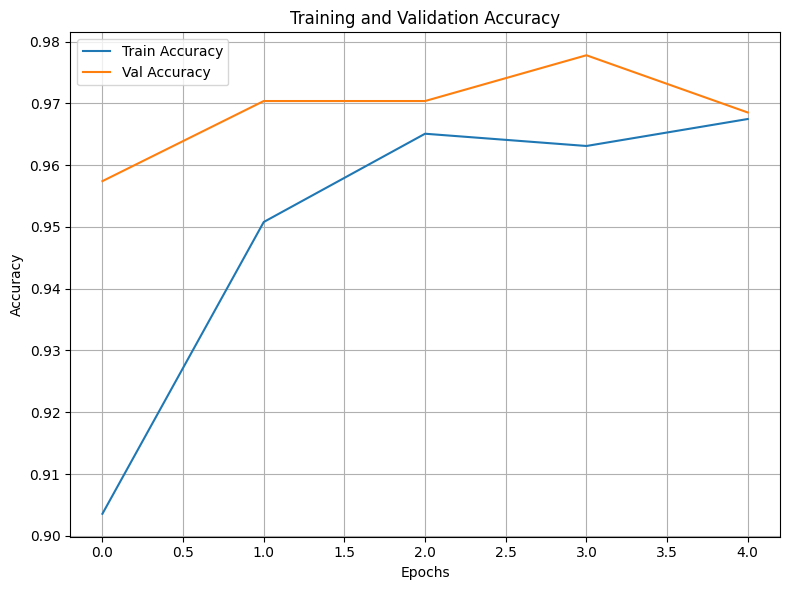

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()

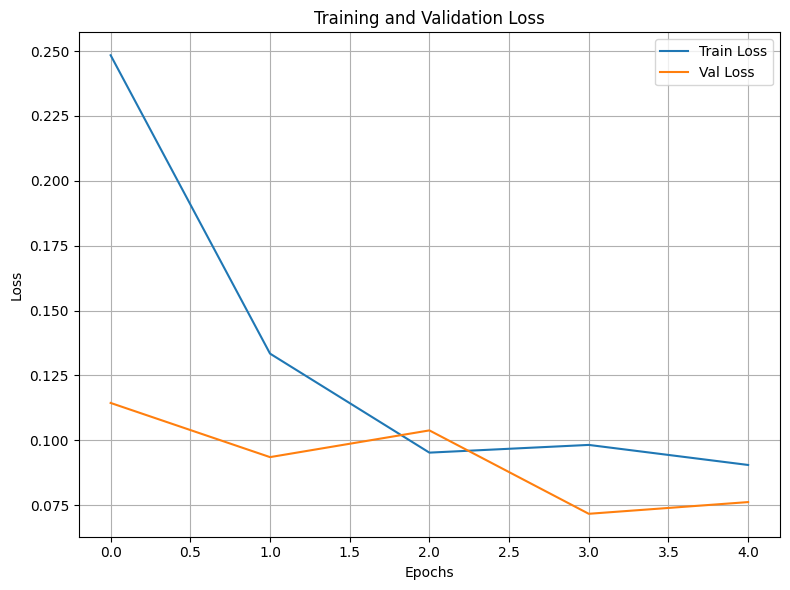

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()

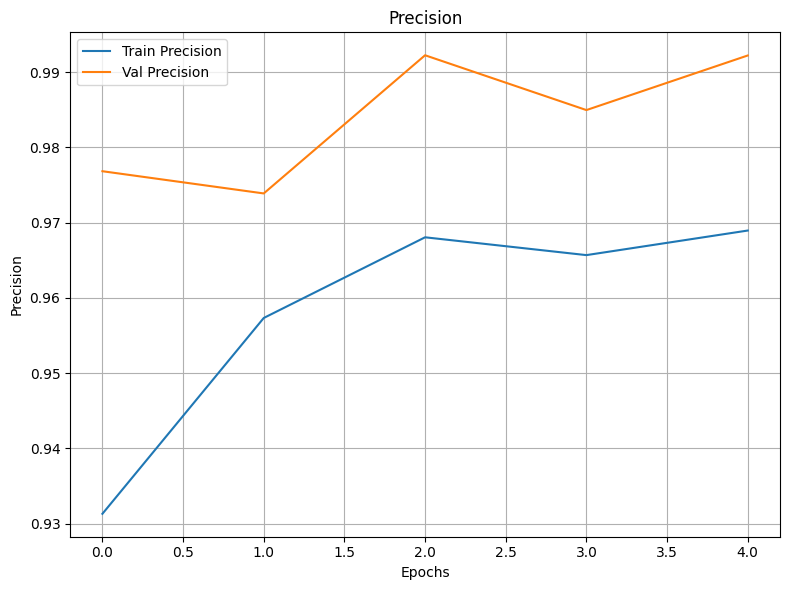

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(train_precisions, label="Train Precision")
plt.plot(val_precisions, label="Val Precision")
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.title('Precision')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()

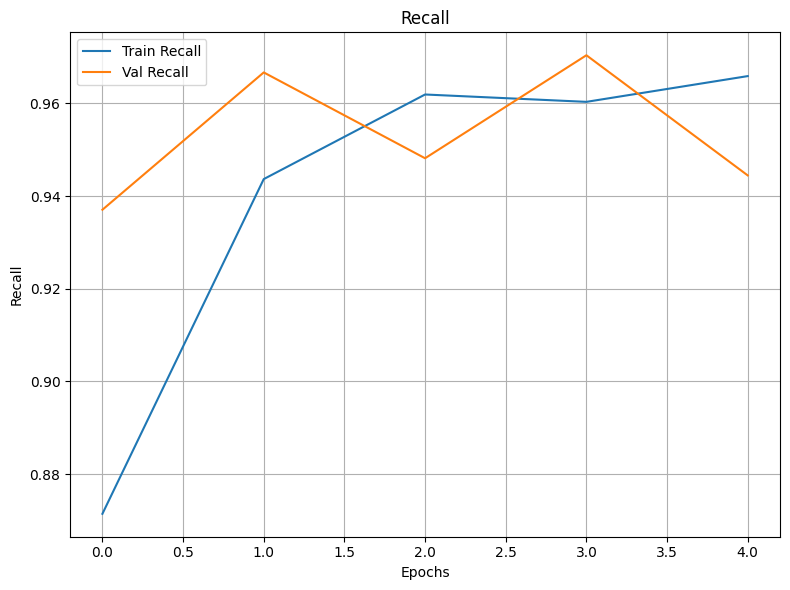

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(train_recalls, label="Train Recall")
plt.plot(val_recalls, label="Val Recall")
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.title('Recall')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()

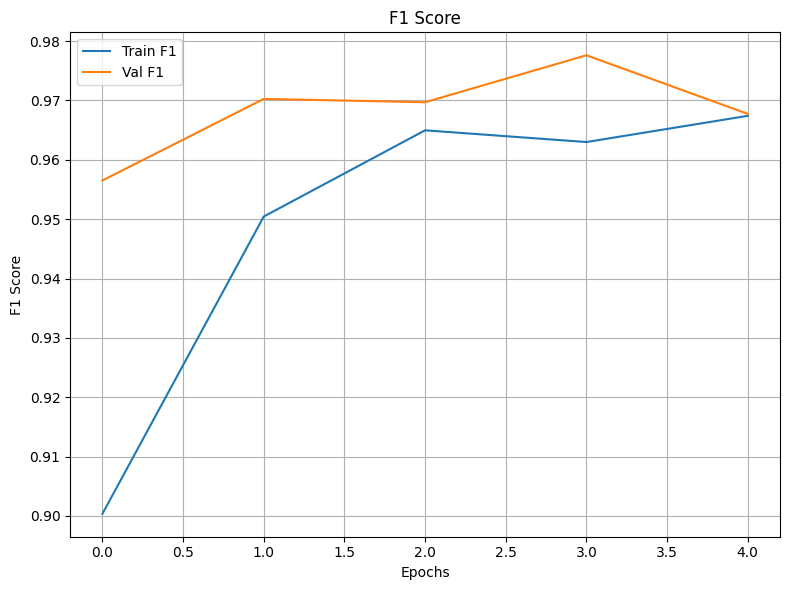

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(train_f1s, label="Train F1")
plt.plot(val_f1s, label="Val F1")
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
class_names = train_dataset.classes
print(f"Class names: {class_names}")

Class names: ['NORMAL', 'PNEUMONIA']


In [ ]:
# Define the paths to save the model
save_path_state_dict = "pruned_RN18_state_dict.pth"
save_path_entire_model = "pruned_entire_RN18.pth"

torch.save(model.state_dict(), save_path_state_dict)
print(f"Model state dictionary saved to {save_path_state_dict}")

torch.save(model, save_path_entire_model)
print(f"Entire model saved to {save_path_entire_model}")

Model state dictionary saved to pruned_RN18_state_dict_X-ray_70%.pth
Entire model saved to pruned_entire_RN18_X-ray_70%.pth


# Pruning Report


This notebook demonstrates the process of applying structural pruning to a MobileNetV2 model using the `torch-pruning` library.

**the type of peuning is:** *Structured Channel Pruning (L2-Magnitude-Based)
specifically, 1×1 convolution channel pruning.*

**Pruning Process Details:**

The core of the pruning process in this notebook revolves around using the `torch-pruning` library to remove channels from specific layers of the MobileNetV2 model. Here's a breakdown of the technical steps:

1.  **Model Preparation:**
    *   A pre-trained MobileNetV2 model is loaded.
    *   The standard classifier is replaced with a custom one tailored for the specific task (binary classification with `num_classes = 1`). This involves adding `Flatten`, `Dropout`, `Linear`, and `ReLU` layers.
    *   Pre-trained weights are loaded into this modified model.
    *   The model is moved to the target device (CPU or GPU).

2.  **Defining Pruning Strategy:**
    *   **Importance Metric:** `tp.importance.MagnitudeImportance(p=2)` is used. This metric calculates the importance of each channel based on the L2 norm (Euclidean distance) of its corresponding weights. Channels with lower magnitude are considered less important and are candidates for removal.
    *   **Pruner Selection:** `tp.pruner.MagnitudePruner` is chosen. This pruner uses the calculated magnitude importance to determine which channels to prune.
    *   **Pruning Ratio:** `pruning_ratio` is set. This indicates that the pruner will attempt to remove a total of 10% of the channels across the *prunable* layers based on their magnitude.
    *   **Ignored Layers:** Specific layers are explicitly excluded from the pruning process using the `ignored_layers` parameter. In this notebook, depthwise convolutional layers (where `groups == in_channels`) and all linear layers in the classifier are ignored. This is a common practice to preserve the core structure and the final output layers of the model.

3.  **Identifying Prunable Layers:**
    *   The code iterates through all modules in the model to find `torch.nn.Conv2d` layers.
    *   **Candidate Prunable Layers:** The notebook specifically identifies 1x1 convolutional layers with `groups == 1` as candidates for pruning. These layers are often good candidates for structural pruning as removing their channels directly impacts the number of input channels of subsequent layers, leading to a reduction in computation.

4.  **Applying Pruning:**
    *   An instance of the `MagnitudePruner` is created with the model, example inputs, importance metric, pruning ratio, and the list of ignored layers.
    *   The `pruner.step()` method is called. This is where the pruning actually happens. The pruner calculates the importance of channels in the prunable layers (excluding ignored ones), identifies the channels to remove based on the `pruning_ratio`, and then structurally modifies the model by removing those channels and updating the weights and biases of connected layers accordingly.

**Results:**

The pruning process successfully reduced the number of parameters in the model by removing channels from the identified prunable 1x1 convolutional layers.


This demonstrates that the pruning was applied as intended, resulting in a smaller model size. The next steps would typically involve fine-tuning the pruned model on the dataset to recover any potential loss in accuracy due to pruning.

| Category           |what is used                           |
| ------------------ | ------------------------------------- |
| **Pruning Type**   | Structured, channel-level pruning |
| **Criterion**      | Magnitude (L2 norm)                   |
| **Target Layers**  | 1×1 Conv2d (pointwise)                |
| **Ignored Layers** | Depthwise Conv2d, Linear layers       |
| **Pruning Ratio**  | pruning_ratio                                 |
| **Framework**      | `torch-pruning`                       |
| **Model**          | MobileNetV2 (custom classifier)       |



Each block has:

1×1 conv (expand)

3×3 depthwise conv (cheap)

1×1 conv (project)

The 1×1 convolutions contain most of the model’s weights — around 90–95% of total parameters.
So pruning them gives you:

🔹 Real reduction in model size
🔹 Actual inference speedup (since it affects dense matrix ops)

Depthwise convolutions, in contrast, are already tiny — pruning them gives little gain but higher risk of accuracy loss.

So focusing on 1×1 convs is both safe and effective.